In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [16]:
import os
import time
import psutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [17]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/therealoise
/kaggle/input/datasets/therealoise/bean-disease-dataset
/kaggle/input/datasets/therealoise/bean-disease-dataset/Bean_Dataset
/kaggle/input/datasets/therealoise/bean-disease-dataset/Bean_Dataset/bean_rust
/kaggle/input/datasets/therealoise/bean-disease-dataset/Bean_Dataset/healthy
/kaggle/input/datasets/therealoise/bean-disease-dataset/Bean_Dataset/angular_leaf_spot


In [18]:
DATASET_PATH = "/kaggle/input/datasets/therealoise/bean-disease-dataset/Bean_Dataset"

In [19]:
for cls in os.listdir(DATASET_PATH):
    print(cls, len(os.listdir(os.path.join(DATASET_PATH, cls))))

bean_rust 330
healthy 330
angular_leaf_spot 330


In [20]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print("Classes:", train_generator.class_indices)

Found 792 images belonging to 3 classes.
Found 198 images belonging to 3 classes.
Classes: {'angular_leaf_spot': 0, 'bean_rust': 1, 'healthy': 2}


In [21]:
def build_model(base_model):

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.3)(x)

    outputs = Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [22]:
results = []

def train_model(model_name, base_model):

    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    model = build_model(base_model)

    params = model.count_params()

    ram_before = psutil.virtual_memory().used / (1024**3)

    start_time = time.time()

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10,
        verbose=1
    )

    training_time = time.time() - start_time

    ram_after = psutil.virtual_memory().used / (1024**3)

    memory_used = abs(ram_after - ram_before)

    loss, accuracy = model.evaluate(
        val_generator,
        verbose=0
    )

    results.append({
        "Model": model_name,
        "Accuracy (%)": round(accuracy*100,2),
        "Parameters": params,
        "Training Time (sec)": round(training_time,2),
        "Memory Used (GB)": round(memory_used,2)
    })

    return model

In [23]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model = train_model(
    "MobileNetV2",
    mobilenet_base
)


Training MobileNetV2
Epoch 1/10


I0000 00:00:1780039593.781497     197 service.cc:152] XLA service 0x78f5d00016c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780039593.781549     197 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780039593.781556     197 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780039594.803155     197 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-29 07:26:43.754916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:26:43.894079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780039605.884051     197 device_co

 4/25 ━━━━━━━━━━━━━━━━━━━━ 7s 362ms/step - accuracy: 0.4049 - loss: 1.4344

2026-05-29 07:26:56.317786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:26:56.456654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:26:56.593627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.4973 - loss: 1.1096

2026-05-29 07:27:24.216206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:27:24.352130: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.5619 - loss: 0.9518 - val_accuracy: 0.7071 - val_loss: 0.6485
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 515ms/step - accuracy: 0.7222 - loss: 0.6562 - val_accuracy: 0.8030 - val_loss: 0.5241
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 526ms/step - accuracy: 0.7790 - loss: 0.5408 - val_accuracy: 0.8081 - val_loss: 0.4463
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 514ms/step - accuracy: 0.7955 - loss: 0.5133 - val_accuracy: 0.8384 - val_loss: 0.4015
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 514ms/step - accuracy: 0.8220 - loss: 0.4502 - val_accuracy: 0.8333 - val_loss: 0.3961
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 513ms/step - accuracy: 0.8169 - loss: 0.4048 - val_accuracy: 0.8535 - val_loss: 0.3710
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 508ms/step - accuracy: 0.8396 - loss: 0.3805 - val_accuracy: 0.8737 - val_loss: 0.3152
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 511ms/step - accuracy: 0.8737 - loss: 0.3351 - val_accuracy: 0.8333 -

In [24]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = train_model(
    "ResNet50",
    resnet_base
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training ResNet50
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 991ms/step - accuracy: 0.3194 - loss: 1.3389 - val_accuracy: 0.3333 - val_loss: 1.1031
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.3093 - loss: 1.2441 - val_accuracy: 0.3384 - val_loss: 1.0986
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 535ms/step - accuracy: 0.3081 - loss: 1.2061 - val_accuracy: 0.3788 - val_loss: 1.0881
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 527ms/step - accuracy: 0.3359 - loss: 1.1406 - val_accuracy: 0.3434 - val_loss: 1.0899
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 519ms/step - accuracy: 0.3144 - loss: 1.1439 - val_accuracy: 0.3434 - val_loss: 1.0981
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 516ms/step - accuracy: 0.3662 - loss: 1.1167 - val_accuracy: 0.3485 - val_loss: 1.0837
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 525ms/step - accuracy: 0.3876 - loss: 1.0940 - val_accuracy: 0.4495 - val_loss: 1.0934
Epoch 8/10
25/25 ━━━━━━━━━━

In [25]:
efficientnet_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

efficientnet_model = train_model(
    "EfficientNetB0",
    efficientnet_base
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training EfficientNetB0
Epoch 1/10


2026-05-29 07:40:37.020351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:37.163465: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:37.500334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:37.641153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:38.422285: E external/local_xla/xla/stream_

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.3722 - loss: 1.1038

2026-05-29 07:40:58.604506: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:58.745672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:59.070918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:59.211702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:40:59.987261: E external/local_xla/xla/stream_

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.3717 - loss: 1.1040

2026-05-29 07:41:18.419302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:41:18.554760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:41:18.863456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:41:19.004779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 07:41:19.755819: E external/local_xla/xla/stream_

25/25 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.3586 - loss: 1.1081 - val_accuracy: 0.3333 - val_loss: 1.0999
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 513ms/step - accuracy: 0.3321 - loss: 1.1197 - val_accuracy: 0.3333 - val_loss: 1.1041
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 510ms/step - accuracy: 0.3409 - loss: 1.1168 - val_accuracy: 0.3333 - val_loss: 1.1022
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 512ms/step - accuracy: 0.3359 - loss: 1.1231 - val_accuracy: 0.3333 - val_loss: 1.1165
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 516ms/step - accuracy: 0.3144 - loss: 1.1265 - val_accuracy: 0.3333 - val_loss: 1.1090
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 513ms/step - accuracy: 0.3144 - loss: 1.1305 - val_accuracy: 0.3333 - val_loss: 1.1093
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 517ms/step - accuracy: 0.3295 - loss: 1.1178 - val_accuracy: 0.3333 - val_loss: 1.1105
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 510ms/step - accuracy: 0.3043 - loss: 1.1279 - val_accuracy: 0.3333 -

In [26]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

comparison_df

,Model,Accuracy (%),Parameters,Training Time (sec),Memory Used (GB)
0,MobileNetV2,87.88,2261827,173.90,0.94
1,ResNet50,46.46,23593859,154.95,0.49
2,EfficientNetB0,33.33,4053414,177.08,0.79


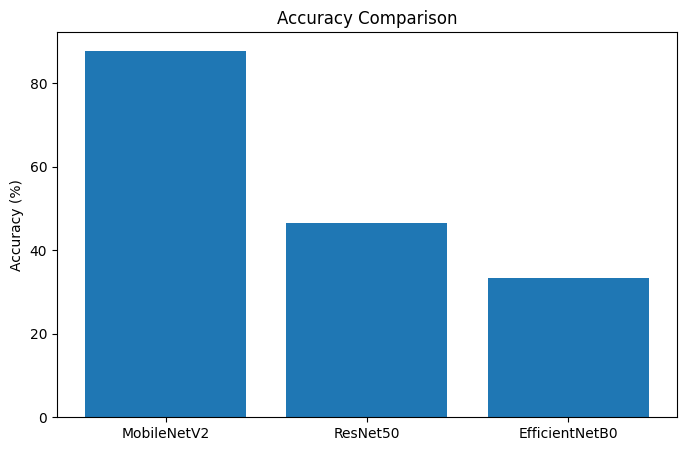

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

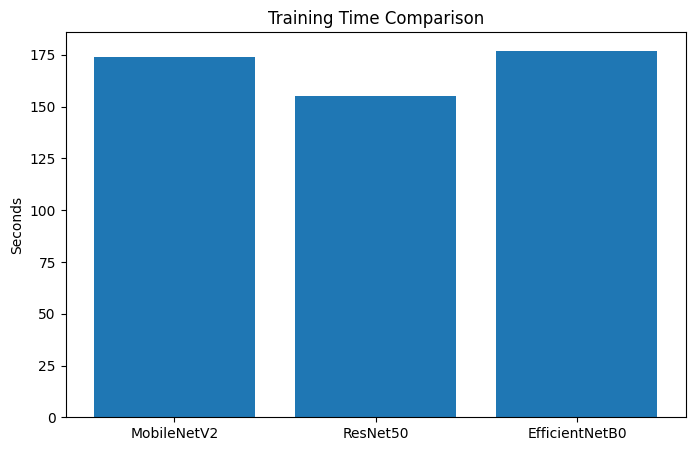

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (sec)"]
)

plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

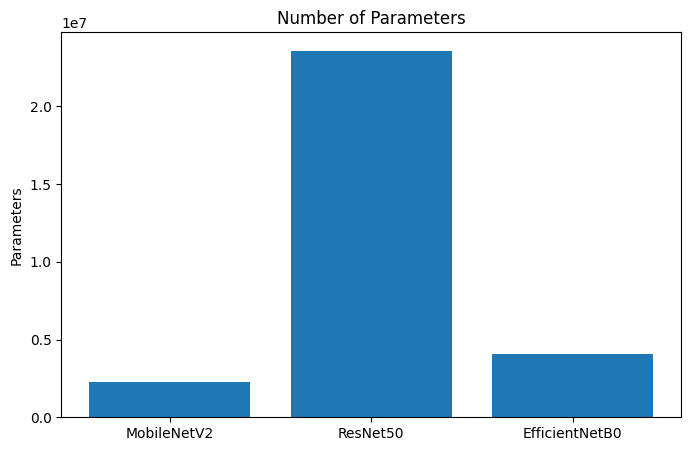

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Parameters"]
)

plt.title("Number of Parameters")
plt.ylabel("Parameters")
plt.show()

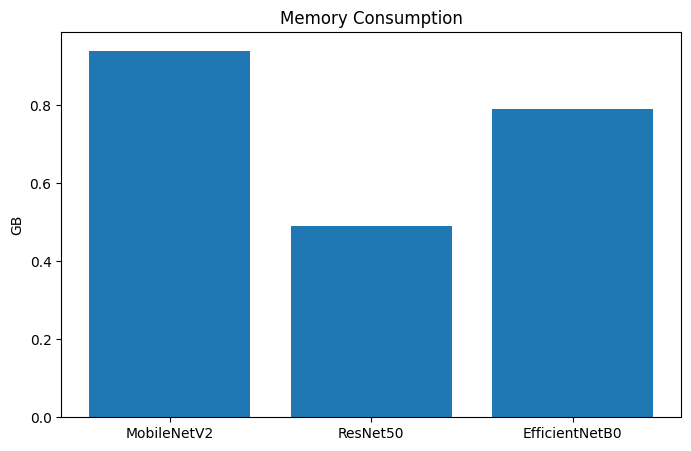

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Memory Used (GB)"]
)

plt.title("Memory Consumption")
plt.ylabel("GB")
plt.show()